In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import DATA_INTERIM, DATA_PROCESSED, OUTPUT_TABLES, OUTPUT_FIGURES

In [5]:
HISTORY_HOURS = 24
STRIDE_HOURS = 1
MIN_COVERAGE = 0.70

WINDOW_MINUTES = HISTORY_HOURS * 60
STRIDE_MINUTES = STRIDE_HOURS * 60

DAY_START = 6 * 60      # 06:00
DAY_END = 22 * 60       # 22:00

In [6]:
clean_path = DATA_INTERIM / "smartwatch_cleaned.parquet"
df = pd.read_parquet(clean_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Users:", df["user_key"].nunique())
df.head()

Shape: (2101759, 9)
Columns: ['user_key', 'date', 'time', 'activity_type', 'intensity', 'steps', 'hr', 'minutes_from_midnight', 'relative_minute']
Users: 20


,user_key,date,time,activity_type,intensity,steps,hr,minutes_from_midnight,relative_minute
0,113,0,09:35:00,80.0,31.0,0.0,NaN,575,575
1,113,0,09:36:00,96.0,6.0,0.0,72.0,576,576
2,113,0,09:37:00,80.0,0.0,0.0,73.0,577,577
3,113,0,09:38:00,80.0,13.0,0.0,74.0,578,578
4,113,0,09:39:00,90.0,20.0,0.0,75.0,579,579


In [7]:
summary = df.groupby("user_key").agg(
    n_rows=("relative_minute", "size"),
    min_minute=("relative_minute", "min"),
    max_minute=("relative_minute", "max"),
    n_days=("date", "nunique")
).reset_index()

summary.sort_values("n_rows", ascending=False).head(10)

,user_key,n_rows,min_minute,max_minute,n_days
0,113,240599,575,264643,179
4,294,224253,0,264080,166
14,702,213400,609,262541,161
6,343,198334,1334,264955,145
19,939,193466,1921,256686,144
1,190,181965,1928,213534,139
13,701,154784,482,160828,110
11,514,134662,2211,264357,99
8,447,123147,1026,131334,91
17,808,83193,1292,222201,64


In [8]:
df["activity_type"] = pd.to_numeric(df["activity_type"], errors="coerce")
df["intensity"] = pd.to_numeric(df["intensity"], errors="coerce")

ACTIVITY_MAP = {
    1: "walk",
    16: "walk",
    33: "walk",

    3: "not_worn",
    6: "charging",

    80: "sedentary",
    89: "sedentary",
    90: "sedentary",
    91: "sedentary",
    92: "sedentary",
    96: "sedentary",

    66: "running",
    82: "running",
    98: "running",

    17: "activity_high",

    106: "sleep",
    112: "sleep",
    121: "sleep",
    122: "sleep",
    123: "sleep",
}

df["activity_group"] = df["activity_type"].map(ACTIVITY_MAP).fillna("unknown")

df["is_active_minute"] = df["activity_group"].isin(
    ["walk", "running", "activity_high"]
).astype(int)

DAY_START = 6 * 60
DAY_END = 22 * 60

df["is_day"] = (
    (df["minutes_from_midnight"] >= DAY_START) &
    (df["minutes_from_midnight"] < DAY_END)
).astype(int)

df["is_night"] = 1 - df["is_day"]

print(df["activity_group"].value_counts(dropna=False))
print(df["activity_type"].value_counts(dropna=False).head(20))

activity_group
sedentary        897389
sleep            694963
walk             239847
unknown          208313
charging          34216
activity_high     22869
running            4111
not_worn             51
Name: count, dtype: int64
activity_type
112.0    587121
80.0     586393
96.0     236383
115.0    194161
1.0      149625
16.0      88253
122.0     76645
90.0      70709
6.0       34216
17.0      22869
121.0     19143
106.0      9083
83.0       4603
99.0       4000
98.0       3409
123.0      2971
89.0       2206
124.0      2157
33.0       1969
26.0       1094
Name: count, dtype: int64


In [9]:
df["activity_group"].value_counts()

activity_group
sedentary        897389
sleep            694963
walk             239847
unknown          208313
charging          34216
activity_high     22869
running            4111
not_worn             51
Name: count, dtype: int64

In [10]:
def safe_slope(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan
    if np.all(x == x[0]):
        return np.nan

    return np.polyfit(x, y, 1)[0]

In [11]:
def extract_window_features(w, user_key, anchor_minute):
    observed_minutes = w["relative_minute"].nunique()
    coverage = observed_minutes / WINDOW_MINUTES

    if coverage < MIN_COVERAGE:
        return None

    hr_valid = w["hr"].dropna()
    steps_valid = w["steps"].dropna()
    intensity_valid = w["intensity"].dropna()

    result = {
        "user_key": user_key,
        "anchor_relative_minute": anchor_minute,
        "window_start_minute": anchor_minute - WINDOW_MINUTES,
        "window_end_minute": anchor_minute,
        "observed_minutes": observed_minutes,
        "coverage": coverage,
        "n_rows_in_window": len(w),

        "hr_mean": hr_valid.mean() if len(hr_valid) else np.nan,
        "hr_std": hr_valid.std() if len(hr_valid) else np.nan,
        "hr_min": hr_valid.min() if len(hr_valid) else np.nan,
        "hr_max": hr_valid.max() if len(hr_valid) else np.nan,
        "hr_median": hr_valid.median() if len(hr_valid) else np.nan,
        "hr_missing_pct": 1 - (w["hr"].notna().sum() / WINDOW_MINUTES),

        "steps_sum": steps_valid.sum() if len(steps_valid) else np.nan,
        "steps_mean": steps_valid.mean() if len(steps_valid) else np.nan,
        "steps_max": steps_valid.max() if len(steps_valid) else np.nan,

        "intensity_mean": intensity_valid.mean() if len(intensity_valid) else np.nan,
        "intensity_std": intensity_valid.std() if len(intensity_valid) else np.nan,
        "intensity_max": intensity_valid.max() if len(intensity_valid) else np.nan,

        "active_minute_frac": w["is_active_minute"].mean(),
    }

    for group in ["walk", "running", "activity_high", "sedentary", "sleep", "not_worn", "charging", "unknown"]:
        result[f"activity_frac_{group}"] = (w["activity_group"] == group).mean()

    day_w = w[w["is_day"] == 1]
    night_w = w[w["is_night"] == 1]

    result["day_hr_mean"] = day_w["hr"].mean()
    result["night_hr_mean"] = night_w["hr"].mean()
    result["day_steps_sum"] = day_w["steps"].sum(min_count=1)
    result["night_steps_sum"] = night_w["steps"].sum(min_count=1)
    result["day_active_frac"] = day_w["is_active_minute"].mean() if len(day_w) else np.nan
    result["night_active_frac"] = night_w["is_active_minute"].mean() if len(night_w) else np.nan

    rel_x = w["relative_minute"] - w["relative_minute"].min()
    result["hr_slope"] = safe_slope(rel_x.values, w["hr"].values)
    result["steps_slope"] = safe_slope(rel_x.values, w["steps"].values)

    return result

In [12]:
feature_rows = []

for user_key, user_df in tqdm(df.groupby("user_key"), desc="Users"):
    user_df = user_df.sort_values("relative_minute").copy()

    min_anchor = user_df["relative_minute"].min() + WINDOW_MINUTES
    max_anchor = user_df["relative_minute"].max()

    anchors = np.arange(min_anchor, max_anchor + 1, STRIDE_MINUTES)

    for anchor in anchors:
        w = user_df[
            (user_df["relative_minute"] >= anchor - WINDOW_MINUTES) &
            (user_df["relative_minute"] < anchor)
        ]

        if len(w) == 0:
            continue

        row = extract_window_features(w, user_key, anchor)
        if row is not None:
            feature_rows.append(row)

features_df = pd.DataFrame(feature_rows)

print("Feature table shape:", features_df.shape)
features_df.head()

Users:   0%|          | 0/20 [00:00<?, ?it/s]

Feature table shape: (33812, 36)


,user_key,anchor_relative_minute,window_start_minute,window_end_minute,observed_minutes,coverage,n_rows_in_window,hr_mean,hr_std,hr_min,...,activity_frac_charging,activity_frac_unknown,day_hr_mean,night_hr_mean,day_steps_sum,night_steps_sum,day_active_frac,night_active_frac,hr_slope,steps_slope
0,113,2015,575,2015,1440,1.0,1440,78.701630,16.003040,1.0,...,0.0,0.015972,82.049019,69.282761,11404.0,10.0,0.218750,0.0,0.003642,0.014601
1,113,2075,635,2075,1440,1.0,1440,79.898827,17.232237,1.0,...,0.0,0.015972,83.667076,69.282761,13443.0,10.0,0.255208,0.0,0.011597,0.022178
2,113,2135,695,2135,1440,1.0,1440,79.590782,16.860334,1.0,...,0.0,0.015972,83.249695,69.282761,15026.0,10.0,0.263542,0.0,0.019989,0.030256
3,113,2195,755,2195,1440,1.0,1440,80.887085,18.562120,1.0,...,0.0,0.015278,85.006119,69.282761,17753.0,10.0,0.312500,0.0,0.029141,0.038322
4,113,2255,815,2255,1440,1.0,1440,82.815147,19.791903,1.0,...,0.0,0.013889,87.606834,69.282761,19523.0,10.0,0.350000,0.0,0.033807,0.038877


In [13]:
print(features_df.describe(include="all").T.head(30))
print("\nUsers in feature table:", features_df["user_key"].nunique())
print("Windows per user:")
display(features_df["user_key"].value_counts().head(20))

                               count           mean           std  \
user_key                     33812.0     500.248728    266.122032   
anchor_relative_minute       33812.0  104532.901840  73297.665874   
window_start_minute          33812.0  103092.901840  73297.665874   
window_end_minute            33812.0  104532.901840  73297.665874   
observed_minutes             33812.0    1432.213327     46.042744   
coverage                     33812.0       0.994593      0.031974   
n_rows_in_window             33812.0    1432.213327     46.042744   
hr_mean                      33181.0      81.621050      9.750218   
hr_std                       33028.0      15.152346      5.217180   
hr_min                       33181.0      16.625418     25.367360   
hr_max                       33181.0     119.733643     17.477556   
hr_median                    33181.0      80.594587     10.834933   
hr_missing_pct               33812.0       0.256684      0.196050   
steps_sum                    33812

user_key
113    3875
294    3629
702    3440
343    3226
939    3123
190    2927
701    2527
514    2174
447    2004
808    1324
917    1263
473    1218
764    1026
625     972
398     712
454     150
328     126
278      96
Name: count, dtype: int64

In [14]:
feature_summary = features_df.describe().T
feature_summary["missing_pct"] = features_df.isna().mean() * 100
feature_summary = feature_summary.sort_index()

feature_summary.to_csv(OUTPUT_TABLES / "baseline_feature_summary.csv")
feature_summary.head(20)

,count,mean,std,min,25%,50%,75%,max,missing_pct
active_minute_frac,33812.0,0.127073,0.069890,0.000000,0.074306,0.125000,0.170833,0.421359,0.000000
activity_frac_activity_high,33812.0,0.010888,0.008248,0.000000,0.004861,0.009722,0.015278,0.056944,0.000000
activity_frac_charging,33812.0,0.015763,0.078841,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
activity_frac_not_worn,33812.0,0.000024,0.000143,0.000000,0.000000,0.000000,0.000000,0.002778,0.000000
activity_frac_running,33812.0,0.001975,0.009927,0.000000,0.000000,0.000000,0.000000,0.148611,0.000000
activity_frac_sedentary,33812.0,0.427278,0.133279,0.000000,0.375694,0.455556,0.514583,0.804576,0.000000
activity_frac_sleep,33812.0,0.330251,0.132670,0.000000,0.295833,0.345139,0.403472,0.770833,0.000000
activity_frac_unknown,33812.0,0.099612,0.219040,0.000000,0.002778,0.009028,0.048611,1.000000,0.000000
activity_frac_walk,33812.0,0.114210,0.062379,0.000000,0.067042,0.111806,0.154167,0.381944,0.000000
anchor_relative_minute,33812.0,104532.901840,73297.665874,1440.000000,42092.000000,87812.000000,160200.250000,264914.000000,0.000000


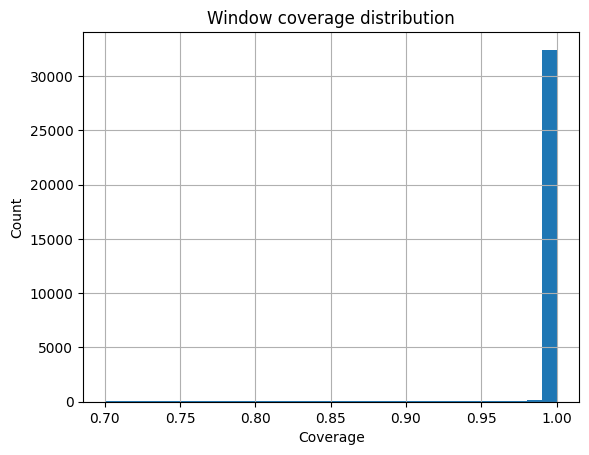

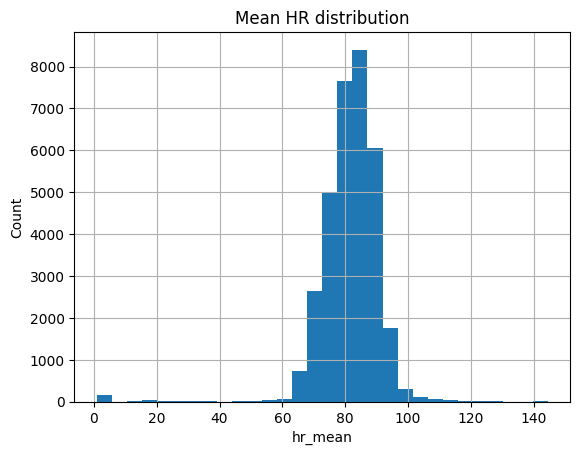

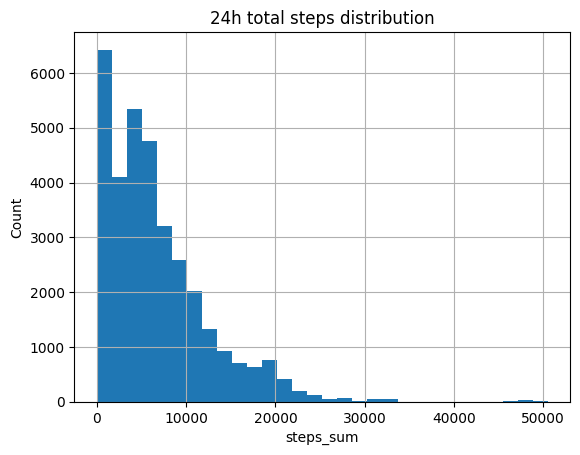

In [15]:
features_df["coverage"].hist(bins=30)
plt.xlabel("Coverage")
plt.ylabel("Count")
plt.title("Window coverage distribution")
plt.show()

features_df["hr_mean"].hist(bins=30)
plt.xlabel("hr_mean")
plt.ylabel("Count")
plt.title("Mean HR distribution")
plt.show()

features_df["steps_sum"].hist(bins=30)
plt.xlabel("steps_sum")
plt.ylabel("Count")
plt.title("24h total steps distribution")
plt.show()

In [16]:
processed_parquet = DATA_PROCESSED / "baseline_smartwatch_features.parquet"
processed_csv = DATA_PROCESSED / "baseline_smartwatch_features.csv"

features_df.to_parquet(processed_parquet, index=False)
features_df.to_csv(processed_csv, index=False)

print("Saved:")
print(processed_parquet)
print(processed_csv)
print(OUTPUT_TABLES / "baseline_feature_summary.csv")

Saved:
C:\Users\user\Desktop\693\project phase 1\data\processed\baseline_smartwatch_features.parquet
C:\Users\user\Desktop\693\project phase 1\data\processed\baseline_smartwatch_features.csv
C:\Users\user\Desktop\693\project phase 1\outputs\tables\baseline_feature_summary.csv


In [17]:
import pandas as pd
from src.config import DATA_INTERIM, DATA_PROCESSED

clean_df = pd.read_parquet(DATA_INTERIM / "smartwatch_cleaned.parquet")
feat_df  = pd.read_parquet(DATA_PROCESSED / "baseline_smartwatch_features.parquet")

clean_users = set(clean_df["user_key"].unique())
feat_users  = set(feat_df["user_key"].unique())

missing_users = sorted(clean_users - feat_users)
extra_users   = sorted(feat_users - clean_users)

print("Users in cleaned data:", len(clean_users), sorted(clean_users))
print("Users in features:", len(feat_users), sorted(feat_users))
print("Missing users (lost between notebook 2 and features):", missing_users)
print("Extra users:", extra_users)

Users in cleaned data: 20 [np.int32(113), np.int32(190), np.int32(217), np.int32(278), np.int32(294), np.int32(328), np.int32(343), np.int32(398), np.int32(447), np.int32(454), np.int32(473), np.int32(514), np.int32(625), np.int32(701), np.int32(702), np.int32(748), np.int32(764), np.int32(808), np.int32(917), np.int32(939)]
Users in features: 18 [np.int64(113), np.int64(190), np.int64(278), np.int64(294), np.int64(328), np.int64(343), np.int64(398), np.int64(447), np.int64(454), np.int64(473), np.int64(514), np.int64(625), np.int64(701), np.int64(702), np.int64(764), np.int64(808), np.int64(917), np.int64(939)]
Missing users (lost between notebook 2 and features): [np.int32(217), np.int32(748)]
Extra users: []


In [18]:
summary = (
    clean_df.groupby("user_key")
    .agg(
        n_rows=("user_key", "size"),
        min_date=("date", "min"),
        max_date=("date", "max"),
        n_days=("date", "nunique"),
        min_rel=("relative_minute", "min"),
        max_rel=("relative_minute", "max"),
        hr_missing_pct=("hr", lambda s: round(s.isna().mean() * 100, 2))
    )
    .reset_index()
    .sort_values("n_rows")
)

display(summary)

print("\nRows for missing users:")
display(summary[summary["user_key"].isin(missing_users)])

,user_key,n_rows,min_date,max_date,n_days,min_rel,max_rel,hr_missing_pct
2,217,918,0,1,2,1300,2217,24.840000
15,748,1439,1,2,2,2588,4026,15.770000
3,278,7188,10,15,6,15594,22781,20.209999
5,328,8943,6,12,7,9629,18586,19.500000
9,454,10408,0,8,9,1168,11575,37.610001
7,398,44734,0,36,33,1016,53018,41.009998
12,625,61218,0,50,46,1062,72969,33.970001
16,764,64085,4,54,47,6727,78852,42.560001
10,473,77270,0,61,60,1172,89067,47.759998
18,917,77753,1,61,56,2599,89080,44.389999



Rows for missing users:


,user_key,n_rows,min_date,max_date,n_days,min_rel,max_rel,hr_missing_pct
2,217,918,0,1,2,1300,2217,24.84
15,748,1439,1,2,2,2588,4026,15.77


In [19]:
HISTORY_HOURS = 24
WINDOW_MINUTES = HISTORY_HOURS * 60

for u in missing_users:
    tmp = clean_df[clean_df["user_key"] == u].sort_values("relative_minute").copy()
    span = tmp["relative_minute"].max() - tmp["relative_minute"].min()
    print(f"\nUser {u}")
    print("rows:", len(tmp))
    print("unique days:", tmp['date'].nunique())
    print("min date:", tmp['date'].min(), "max date:", tmp['date'].max())
    print("time span in minutes:", span)
    print("time span in hours:", round(span / 60, 2))
    print("enough span for 24h window?:", span >= WINDOW_MINUTES)


User 217
rows: 918
unique days: 2
min date: 0 max date: 1
time span in minutes: 917
time span in hours: 15.28
enough span for 24h window?: False

User 748
rows: 1439
unique days: 2
min date: 1 max date: 2
time span in minutes: 1438
time span in hours: 23.97
enough span for 24h window?: False


user 217 and user 748 disappeared because they don't have enough required data.